In [1]:
import matplotlib.pyplot as plt
import numpy as np

from geod67lib.normalization import create_normalization_transforms
from geod67lib.wavefield import ricker
import json


2026-07-07 21:37:13.003686: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
norm, denorm = create_normalization_transforms(1.5*.9, 4.5*1.1)

In [35]:
1.5*.9, 4.5*1.1

(1.35, 4.95)

In [74]:
x = np.linspace(1.36, 4.9, num=200)
y = np.linspace(norm(x).numpy().min(), norm(x).numpy().max(), num=200)

Text(0, 0.5, '$T$')

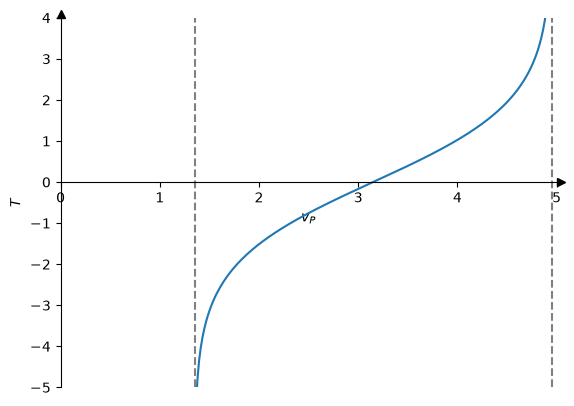

In [88]:
plt.figure()
ax = plt.gca()
plt.plot(x, norm(x))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.set_xlim(0, 5)
ax.set_ylim(-5, 4)
ax.plot([5.04], [0], '>k', clip_on=False)
ax.plot([0], [4.1], '^k', clip_on=False)
ax.plot([1.35, 1.35], [-5, 4], '--', color='grey')
ax.plot([4.95, 4.95], [-5, 4], '--', color='grey')
# ax.grid()
# ax.plot([0, 5], [0, 0], '>k', clip_on=False)
ax.set_xlabel('$v_P$')
ax.set_ylabel('$T$')


Text(0, 0.5, '$T^{-1}$')

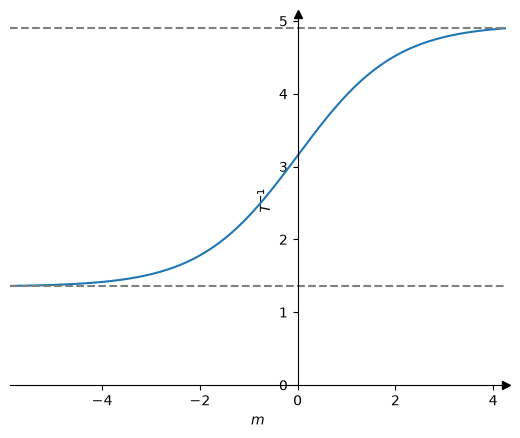

In [91]:
plt.figure()
ax = plt.gca()
plt.plot(y, denorm(y))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.set_xlim(y.min(), y.max())
ax.set_ylim(0)
ax.plot([y.min(), y.max()], [denorm(y).numpy().max(), denorm(y).numpy().max()], '--', color='grey')
ax.plot([y.min(), y.max()], [denorm(y).numpy().min(), denorm(y).numpy().min()], '--', color='grey')
ax.plot([y.max()], [0], '>k', clip_on=False)
ax.plot([0], [denorm(y).numpy().max() + .2], '^k', clip_on=False)
# ax.grid()
# ax.plot([0, 5], [0, 0], '>k', clip_on=False)
ax.set_xlabel('$m$')
ax.set_ylabel('$T^{-1}$')


In [111]:
t = np.linspace(0, 300, num=150)

Text(0, 0.5, '$s(t)$')

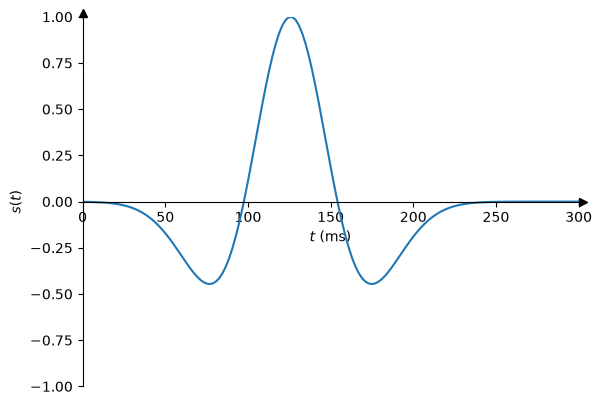

In [128]:
plt.figure()
ax = plt.gca()
plt.plot(t, ricker(8, 2e-3, 150))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
ax.set_xlim(0, t.max())
ax.set_ylim(-1, 1)
ax.plot([t.max()+2.5], [0], '>k', clip_on=False)
ax.plot([0], [1.019], '^k', clip_on=False)
# ax.grid()
# ax.plot([0, 5], [0, 0], '>k', clip_on=False)
ax.set_xlabel('$t$ (ms)')
ax.set_ylabel('$s(t)$')


In [2]:
with open('./data/vp_inv_it1500nbl40-prelu.bin.history.json', 'r') as fin:
    history = json.load(fin)

In [8]:
loss_best = []
for l in history['loss']:
    if len(loss_best) == 0:
        loss_best.append(l)
    elif loss_best[-1] < l:
        loss_best.append(loss_best[-1])
    else:
        loss_best.append(l)

In [20]:
it = np.arange(len(loss_best)) + 1

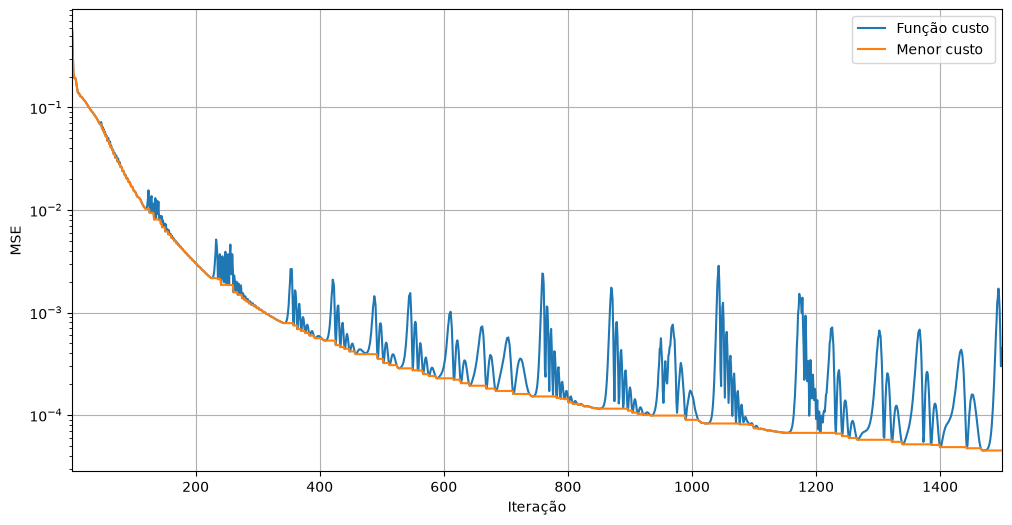

In [29]:
plt.figure(figsize=(12, 6))
plt.semilogy(it, history['loss'], label='Função custo')
plt.semilogy(it, loss_best, label='Menor custo')
plt.legend()
plt.xlabel('Iteração')
plt.ylabel('MSE')
plt.xlim(it.min(), it.max())
plt.grid()